### Ноутбук с проверкой предположения о том что доли ДХ с кредитами в разрезе сбережений ведут себя по-разному 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
from structuralvar import Clean, SVAR_KL

data = pd.read_excel('data/structural_shocks.xlsx').set_index('Unnamed: 0').rename_axis(None, axis = 0)
sd_df = pd.read_excel('data/sd.xlsx').set_index('Unnamed: 0').rename_axis(None, axis = 0).set_axis(['s1d0', 's0d0'])
data = data.loc[:, data.columns[71:]].copy()
data.loc['s1d0', :] = sd_df.iloc[0, :-1].to_numpy()
data.loc['s0d0', :] = sd_df.iloc[1, :-1].to_numpy()
data = data.set_axis(pd.DatetimeIndex(data.columns), axis=1)


In [2]:
data.loc['s1d1'] = 1 - data.loc['s1d0'].copy()/100
data.loc['s0d1'] = 1 - data.loc['s0d0'].copy()/100

Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор
Уровни не переданны, использовал единичный вектор


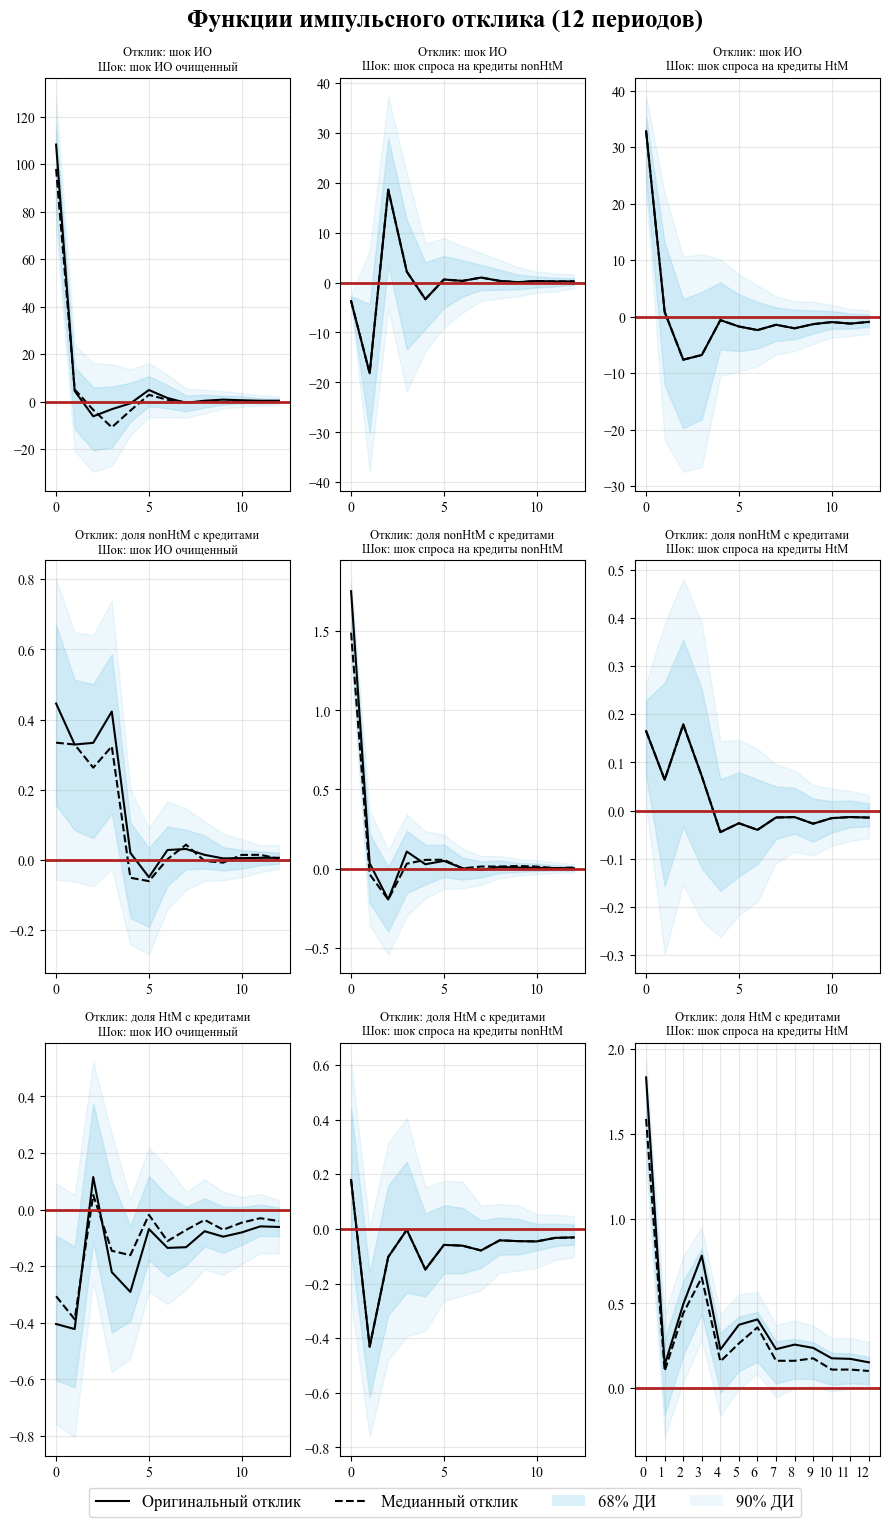

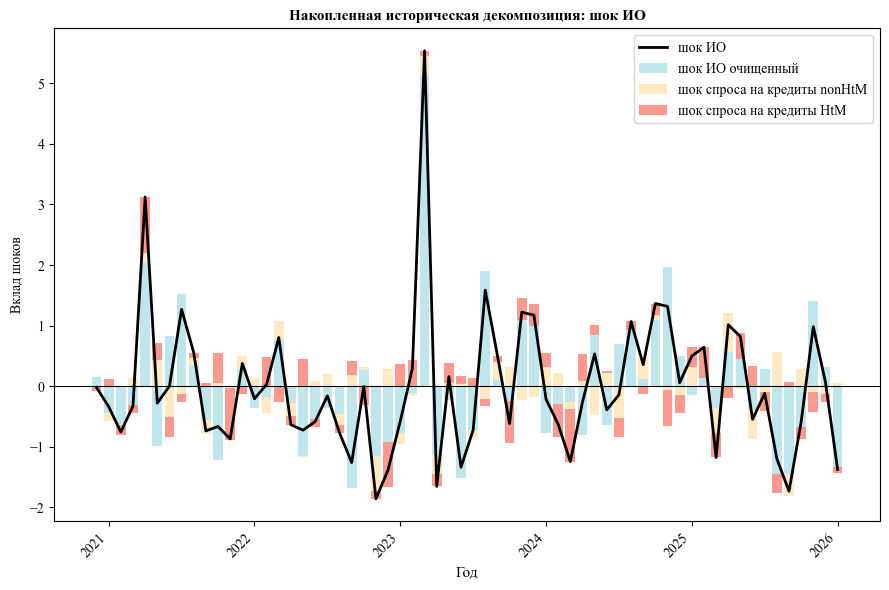

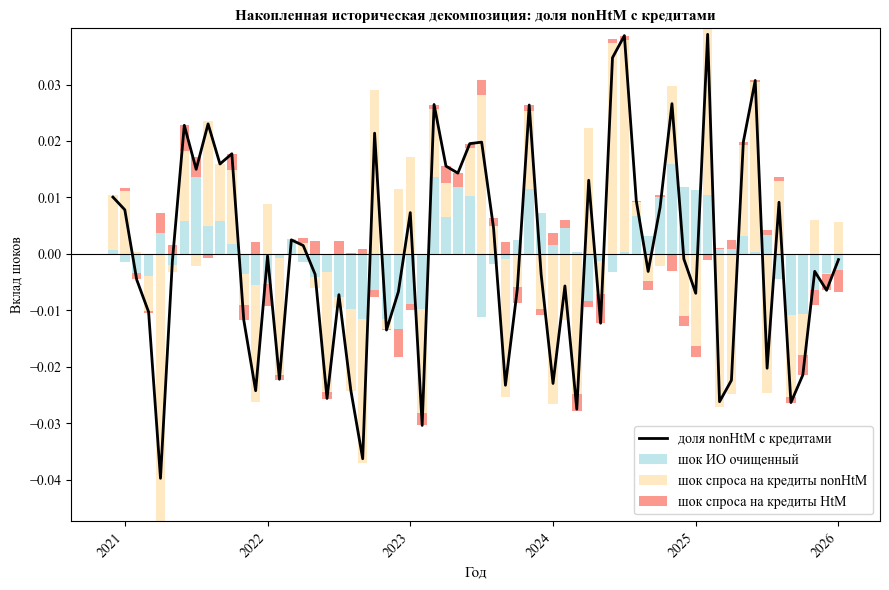

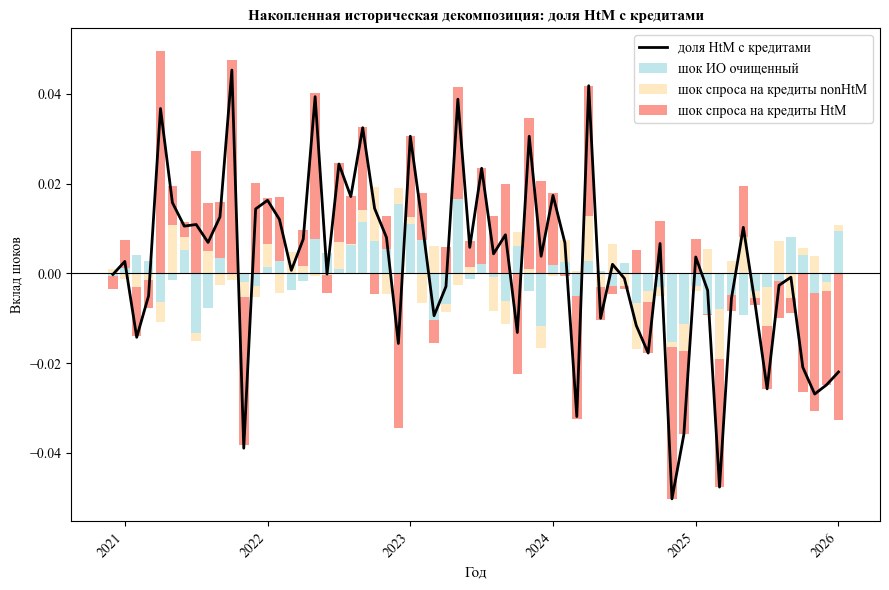

In [3]:
short_run_anchor = [

]
long_run_anchor = [
    (0, 0, 1, 10),
    (0, 0, 2, 10),
]
short_run_signs = [(0, 0, 0, True, 0, 1),
                   (0, 1, 1, True, 0, 1),
                   (0, 2, 2, True, 0, 1),
                   ]
long_run_signs = [
    
]

lag = 3

endog_names = ['pi_e', 's1d1', 's0d1']


df_endog = data.loc[endog_names, :]   # K×T

model_epe = SVAR_KL(
    data=df_endog,
    p=lag,             #
    layout="KL_KxT",
    time_order="chronological",
    add_const=True,
    u_dict = ['шок ИО очищенный', 'шок спроса на кредиты nonHtM', 'шок спроса на кредиты HtM'],
    y_dict = ['шок ИО', 'доля nonHtM c кредитами', 'доля HtM с кредитами']
).fit_ols()

rr = model_epe.identify_combined(
    short_run_anchor=short_run_anchor,
    long_run_anchor=long_run_anchor,
    short_run_signs=short_run_signs,
    long_run_signs=long_run_signs,
    n_starts=100,
    seed=100,
    method="BFGS",
)

horizon = 12
irf0 = model_epe.irf(horizon=horizon)   # (horizon+1, K, K)
required = 1000

irf_draws = model_epe.irf_bootstrap(
    horizon=horizon,
    n_boot=required-1,
    seed=1,
    scheme="fixed_Q",
)

irf_sims = [irf0] + [irf_draws[b] for b in range(irf_draws.shape[0])]
model_epe.plot_irfs_grid(irf_sims=irf_sims,
                     horizon_plot=12,
                     main_color='skyblue')
hd = model_epe.historical_decomposition(plot_hd=True,
                                    init_clean = True,
                                    exog_clean = True,
                                    const_clean = True)

The horizon_plot is greater than it was simulated. Max horizon was obtained from sims


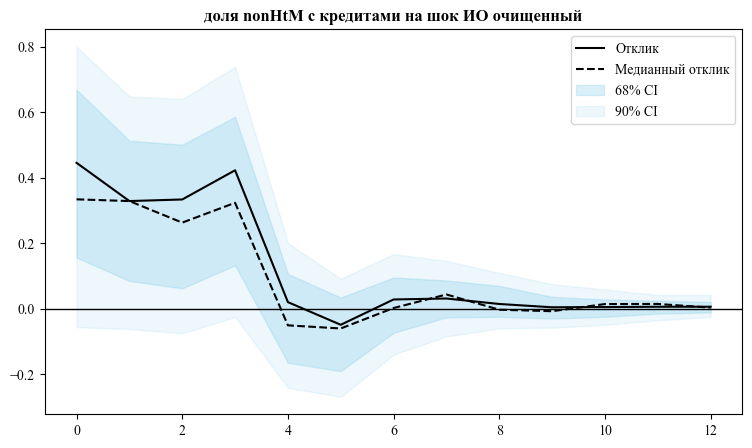

In [4]:
model_epe.plot_single_irf(irf_sims,
                's1d1',
                'шок ИО очищенный',
                'skyblue',
                plot_simulations = False,
                horizon=20,
                cumm = False)

The horizon_plot is greater than it was simulated. Max horizon was obtained from sims


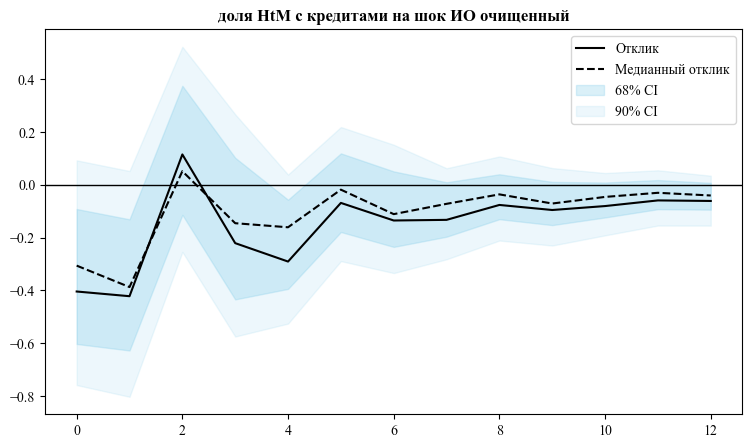

In [5]:
model_epe.plot_single_irf(irf_sims,
                's0d1',
                'шок ИО очищенный',
                'skyblue',
                plot_simulations = False,
                horizon=20,
                cumm = False)

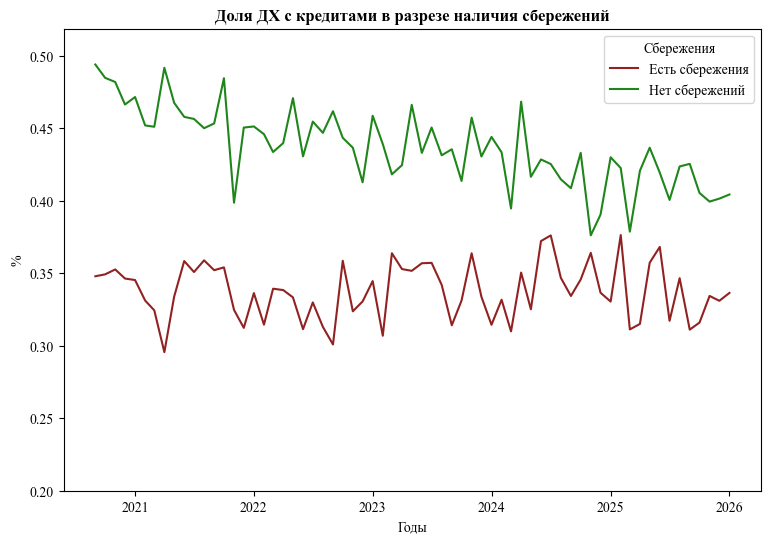

In [6]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False
# =====================================================
#  ЦВЕТА
# =====================================================
nonhtm_color = "#922222"  # бордовый - есть сбережения
htm_color = "#1f861b"     # зелёный - нет сбережений
plt.figure(figsize=(9,6))
x_axis = data.columns
plt.plot(x_axis, data.loc['s1d1'], color=nonhtm_color, label="Есть сбережения")
plt.plot(x_axis, data.loc['s0d1'], color=htm_color, label="Нет сбережений")
plt.axhline(0, color="black", lw=1)
plt.legend(title = "Сбережения")
plt.ylim(0.2)
plt.ylabel('%')
plt.xlabel('Годы')
plt.title("Доля ДХ с кредитами в разрезе наличия сбережений", fontweight='bold')
plt.show()


In [7]:
data.loc['s1d0'].describe()

count    65.000000
mean     66.240713
std       1.938381
min      62.368816
25%      64.792899
50%      66.359447
75%      67.559524
max      70.444763
Name: s1d0, dtype: float64

In [8]:
data.loc['s0d0'].describe()

count    65.000000
mean     56.311022
std       2.696849
min      50.609756
25%      54.545455
50%      56.454248
75%      58.069884
max      62.389735
Name: s0d0, dtype: float64